In [ ]:
cases_path = '/home/yb107/cvit-work/cvpr2025/SAT/data/test_cases'

import numpy as np
import matplotlib.pyplot as plt
import os

In [45]:
def plot_slice(data, title=None, cmap='gray'):
    """
    Plot a single slice of 3D data.
    
    Parameters:
        data (numpy.ndarray): 3D data array.
        slice_index (int): Index of the slice to plot.
        title (str): Title for the plot.
        cmap (str): Colormap for the plot.
    """
    plt.imshow(data, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def plot_3d_segmentation_slice(data, seg_data, title=None, cmap='gray'):
    """
    Plot a single slice of 3D data with segmentation overlay.
    
    Parameters:
        data (numpy.ndarray): 3D data array.
        seg_data (numpy.ndarray): 3D segmentation array.
        title (str): Title for the plot.
        cmap (str): Colormap for the plot.
    """
    plt.imshow(data, cmap=cmap)
    plt.imshow(seg_data, alpha=0.7, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def get_nonzero_channels(data):
    """
    Get the indices of non-zero channels in a 3D data array.
    
    Parameters:
        data (numpy.ndarray): 3D data array.
    
    Returns:
        list: List of indices of non-zero channels.
    """
    nonzero_channels = []
    for i in range(data.shape[0]):
        if np.any(data[i] != 0):
            nonzero_channels.append(i)
    return nonzero_channels

def get_nonzero_slices(data):
    """
    Get the indices of non-zero slices in a 3D data array.
    
    Parameters:
        data (numpy.ndarray): 3D data array.
    
    Returns:
        list: List of indices of non-zero slices.
    """
    nonzero_slices = []
    for i in range(data.shape[2]):
        if np.any(data[:, :, i] != 0):
            nonzero_slices.append(i)
    return nonzero_slices

In [48]:
files = os.listdir(cases_path)
file = files[1]
print(file)

file_path = os.path.join(cases_path, file)
npz = np.load(file_path, allow_pickle=True)
image = npz['image']
mask = npz['mask']
text = npz['text']
print(image.shape)
print(mask.shape)
print(text.shape)
print(get_nonzero_channels(mask))
print(get_nonzero_slices(mask[0]))


CT_COVID-19-20-CT-SegChallenge_volume-covid19-A-0407.npz
(3, 288, 288, 96)
(10, 288, 288, 96)
(1, 10)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]


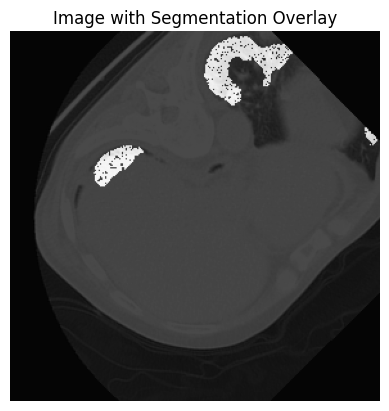

In [53]:
slice_index = 85
img_data = image[0, :, :, slice_index]
seg_data = mask[2, :, :, slice_index]
plot_3d_segmentation_slice(img_data, seg_data, title='Image with Segmentation Overlay', cmap='gray')
